# Constant Time Lag at Any Eccentricity and Obliquity: Hut (1981)

For the constant-time-lag model, where the degree-2 Love number is $k_2(\omega) = k_2 (1 - i \omega \Delta t)$, the tidal dissipation and torque of a body on an eccentric orbit have closed forms that are exact in eccentricity (Hut 1981). Levrard et al. (2007) and Leconte et al. (2010) added the obliquity $\varepsilon$ of the body's spin axis. With $x = \cos\varepsilon$ and the spin rate $\omega$,

$$\dot{E} = 2K \left[ N_a(e) - 2 N(e)\, x \frac{\omega}{n} + \frac{1 + x^2}{2}\, \Omega(e) \left(\frac{\omega}{n}\right)^2 \right], \qquad
T = \frac{K}{n} \left[ 2 N(e)\, x - (1 + x^2)\, \Omega(e) \frac{\omega}{n} \right],$$

$$K = \frac{3}{2} k_2 \Delta t \frac{G M_\star^2}{R} \left(\frac{R}{a}\right)^6 n^2,$$

$$N_a(e) = \frac{1 + \frac{31}{2} e^2 + \frac{255}{8} e^4 + \frac{185}{16} e^6 + \frac{25}{64} e^8}{(1 - e^2)^{15/2}}, \quad
N(e) = \frac{1 + \frac{15}{2} e^2 + \frac{45}{8} e^4 + \frac{5}{16} e^6}{(1 - e^2)^{6}}, \quad
\Omega(e) = \frac{1 + 3 e^2 + \frac{3}{8} e^4}{(1 - e^2)^{9/2}}.$$

TidalPy reaches the same quantities another way: it sums the Kaula (1964) modes of the degree-2 tidal potential, with eccentricity functions tabulated as truncated power series in $e$ and obliquity functions in their exact form. The closed forms are the heating and torque averaged over the argument of periapsis, which is what the 1D Kaula sum computes, so the two should agree to the truncation error. This benchmark checks that for a hot Jupiter, and measures how far each truncation level can be trusted.

References: Hut, P. (1981), A&A 99, 126. Levrard, B., Correia, A. C. M., Chabrier, G., et al. (2007), A&A 462, L5. Leconte, J., Chabrier, G., Baraffe, I., and Levrard, B. (2010), A&A 516, A64. Kaula, W. M. (1964), Rev. Geophys. 2, 661.

In [1]:
%matplotlib inline
import math

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from TidalPy.constants import G, mass_solar, mass_jupiter, radius_jupiter
from TidalPy.structures_x import build_world


def hut_na(e):
    e2 = e * e
    return (1 + 31 / 2 * e2 + 255 / 8 * e2**2 + 185 / 16 * e2**3 + 25 / 64 * e2**4) / (1 - e2) ** 7.5


def hut_n(e):
    e2 = e * e
    return (1 + 15 / 2 * e2 + 45 / 8 * e2**2 + 5 / 16 * e2**3) / (1 - e2) ** 6


def hut_omega(e):
    e2 = e * e
    return (1 + 3 * e2 + 3 / 8 * e2**2) / (1 - e2) ** 4.5


# A hot Jupiter around a Sun-like star on a 3 day orbit.
K2 = 0.3                    # static Love number
TIME_LAG = 60.0             # [s]
RADIUS = 1.2 * radius_jupiter
MASS = mass_jupiter
HOST = mass_solar
N_ORBIT = 2.0 * math.pi / (3.0 * 86400.0)
A_ORBIT = (G * (HOST + MASS) / N_ORBIT**2) ** (1.0 / 3.0)
K_FACTOR = 1.5 * K2 * TIME_LAG * (G * HOST**2 / RADIUS) * (RADIUS / A_ORBIT) ** 6 * N_ORBIT**2


def closed_heating(e, obliquity, spin_ratio):
    x = math.cos(obliquity)
    return 2.0 * K_FACTOR * (hut_na(e) - 2.0 * hut_n(e) * x * spin_ratio
                             + 0.5 * (1.0 + x * x) * hut_omega(e) * spin_ratio**2)


def closed_torque(e, obliquity, spin_ratio):
    x = math.cos(obliquity)
    return K_FACTOR / N_ORBIT * (2.0 * hut_n(e) * x - (1.0 + x * x) * hut_omega(e) * spin_ratio)


planet = build_world({
    "schema_version": "0.2.0", "name": "hot_jupiter", "type": "gasgiant", "radius_m": RADIUS, "mass_kg": MASS,
    "layers": {"envelope": {"class": "gas", "type": "gas", "radius_fraction": 1.0}},
    "tides": {"global_tidal_model": "fixed_dt", "fixed_k": [K2], "fixed_dt_s": [TIME_LAG],
              "min_degree_l": 2, "max_degree_l": 2, "eccentricity_trunc_lvl": 50, "obliquity_trunc_lvl": "gen"}})


def tidalpy(e, obliquity, spin_ratio):
    "TidalPy's heating [W] and the torque on the planet's spin [N m], M_star dU/dO."
    planet.calc_tides(N_ORBIT, spin_ratio * N_ORBIT, e, obliquity, A_ORBIT, HOST)
    return planet.get_tidal_heating(), HOST * planet.get_tidal_potential_derivatives()[2]


print(f"semi-major axis {A_ORBIT / 1.495978707e11:.4f} au, K = {K_FACTOR:.4e} W")

semi-major axis 0.0407 au, K = 3.4043e+23 W


## Heating and Torque across Eccentricity, Obliquity, and Spin

The eccentricity functions are tabulated at level 50 (every product of two of them through $e^{50}$) and the obliquity functions are exact (`obliquity_trunc_lvl = "gen"`). Up to $e = 0.3$, TidalPy matches both closed forms to about $10^{-15}$ in heating and torque, at synchronous and non-synchronous spin and at small and large obliquity; the $10^{-13}$ at $e = 0.01$ is the rounding of the closed form's $N_a - 2N + \Omega$, which nearly cancels at small $e$.

In [2]:
cases = [(0.01, 0.0, 1.0), (0.1, 0.0, 1.0), (0.3, 0.0, 1.0), (0.3, 0.0, 2.3), (0.0, 0.5, 1.0),
         (0.2, 0.5, 1.37), (0.3, 1.2, 0.8), (0.1, 2.5, 1.0), (0.2, 0.3, 0.0)]
print(f"{'e':>5} {'obliquity':>10} {'spin/n':>7} {'heating [W]':>13} {'rel. error':>11} {'torque [N m]':>14} {'rel. error':>11}")
for e, obliquity, spin_ratio in cases:
    heating, torque = tidalpy(e, obliquity, spin_ratio)
    heating_ref = closed_heating(e, obliquity, spin_ratio)
    torque_ref = closed_torque(e, obliquity, spin_ratio)
    print(f"{e:5.2f} {obliquity:10.2f} {spin_ratio:7.2f} {heating:13.5e} {heating / heating_ref - 1:+11.1e} "
          f"{torque:+14.5e} {torque / torque_ref - 1:+11.1e}")

    e  obliquity  spin/n   heating [W]  rel. error   torque [N m]  rel. error
 0.01       0.00    1.00   2.38733e+20    -4.0e-13   +1.68654e+25    +3.4e-13
 0.10       0.00    1.00   2.84153e+22    +5.6e-15   +1.81798e+27    -7.8e-16
 0.30       0.00    1.00   8.74819e+23    -1.1e-15   +3.04529e+28    +8.9e-16
 0.30       0.00    2.30   1.19476e+24    -3.2e-15   -4.06056e+28    -4.4e-16
 0.00       0.50    1.00   8.84517e+22    +2.2e-16   -2.10462e+26    +4.0e-15
 0.20       0.50    1.37   3.31091e+23    -1.4e-15   -4.63997e+27    -1.1e-16
 0.30       1.20    0.80   2.95971e+24    +4.4e-16   +6.10647e+27    +1.3e-15
 0.10       2.50    1.00   2.69899e+24    -4.4e-16   -5.05562e+28    -3.3e-16
 0.20       0.30    0.00   1.54596e+24    -1.0e-15   +4.48738e+28    -5.6e-16


## Pseudo-Synchronous Rotation

The torque vanishes at a spin rate slightly faster than the mean motion, $\omega_\mathrm{eq}/n = N(e)/\Omega(e)$ at zero obliquity (Hut 1981), where the torque near periapse, which pushes the spin toward the fast periapse angular velocity, balances the rest of the orbit. Finding where TidalPy's spin torque changes sign reproduces it.

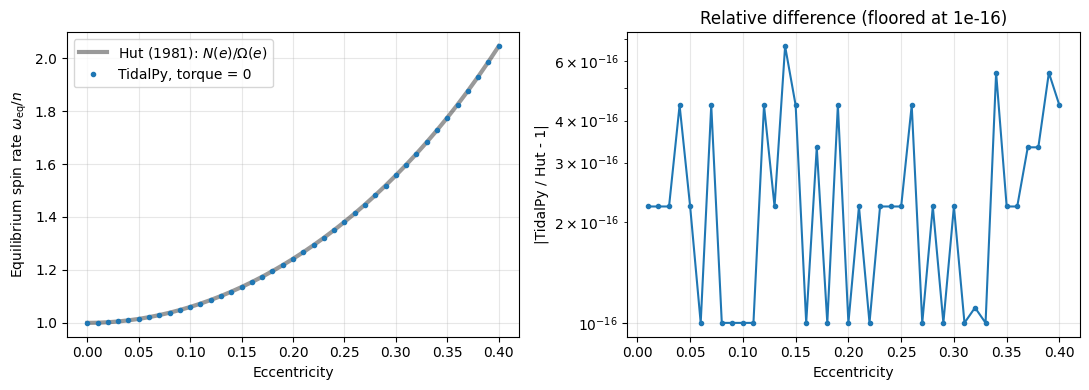

In [3]:
eccentricities = np.linspace(0.0, 0.4, 41)
equilibrium = np.array([brentq(lambda s: tidalpy(e, 0.0, s)[1], 0.5, 5.0, xtol=1e-13) for e in eccentricities])
hut = np.array([hut_n(e) / hut_omega(e) for e in eccentricities])

fig, (ax, ax_err) = plt.subplots(1, 2, figsize=(11, 4))
ax.plot(eccentricities, hut, "k-", lw=3, alpha=0.4, label=r"Hut (1981): $N(e)/\Omega(e)$")
ax.plot(eccentricities, equilibrium, "C0.", label="TidalPy, torque = 0")
ax.set_xlabel("Eccentricity")
ax.set_ylabel(r"Equilibrium spin rate $\omega_\mathrm{eq}/n$")
ax.legend()
ax.grid(alpha=0.3)
ax_err.semilogy(eccentricities[1:], np.maximum(np.abs(equilibrium[1:] / hut[1:] - 1), 1e-16), "C0.-")
ax_err.set_xlabel("Eccentricity")
ax_err.set_ylabel("|TidalPy / Hut - 1|")
ax_err.set_title("Relative difference (floored at 1e-16)")
ax_err.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## How Far Each Truncation Can Be Trusted

The closed form is exact at any eccentricity below 1, so it measures the truncation error of the tabulated eccentricity functions directly. The figure shows the error in synchronous-rotation heating for each truncation level. Level $N$ keeps every product of two eccentricity functions through $e^N$, so the mode sum is the Taylor series of the heating through $e^N$ (see the eccentricity functions page of the documentation). Every level undershoots, and a higher level is never less accurate. At high eccentricity the mode sum of the highest levels cancels heavily, which limits them to $e \lesssim 0.78$ in practice, and a world's tidal solve warns, once per world, from the eccentricity where its level can be 10% low. The dashed lines are the `"exact"` option, which takes the eccentricity functions from the exact Kepler orbit and keeps the modes its tolerance asks for: its error stays below the tolerance at every eccentricity shown.

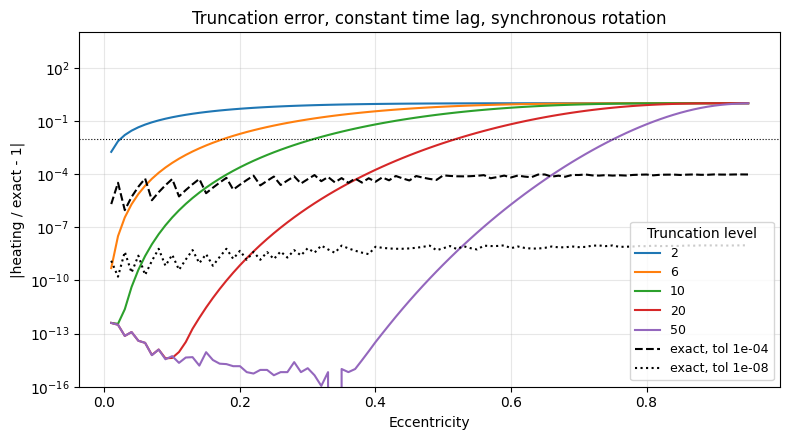

Largest eccentricity with relative error below 1e-6 and 1e-2, and the largest error below e = 0.8:
  level 2  : 1e-6 up to e = 0.00, 1e-2 up to e = 0.02, largest overshoot 0.0e+00
  level 6  : 1e-6 up to e = 0.03, 1e-2 up to e = 0.17, largest overshoot 0.0e+00
  level 10 : 1e-6 up to e = 0.11, 1e-2 up to e = 0.31, largest overshoot 0.0e+00
  level 20 : 1e-6 up to e = 0.29, 1e-2 up to e = 0.52, largest overshoot 1.2e-13
  level 50 : 1e-6 up to e = 0.59, 1e-2 up to e = 0.75, largest overshoot 1.2e-13
  exact, tolerance 1e-04: largest error 9.6e-05 (e up to 0.95), largest overshoot 0.0e+00
  exact, tolerance 1e-08: largest error 9.6e-09 (e up to 0.95), largest overshoot 0.0e+00


In [4]:
levels = (2, 6, 10, 20, 50)
exact_tolerances = (1e-4, 1e-8)
eccentricities = np.linspace(0.01, 0.95, 95)
errors = {}
for level in levels:
    planet.set_tide_config(eccentricity_truncation=level, obliquity_truncation=0)
    errors[level] = np.array([tidalpy(e, 0.0, 1.0)[0] / closed_heating(e, 0.0, 1.0) - 1.0 for e in eccentricities])
for tolerance in exact_tolerances:
    planet.set_tide_config(eccentricity_truncation="exact", eccentricity_exact_tolerance=tolerance,
                           obliquity_truncation=0)
    errors[tolerance] = np.array([tidalpy(e, 0.0, 1.0)[0] / closed_heating(e, 0.0, 1.0) - 1.0
                                  for e in eccentricities])

fig, ax = plt.subplots(figsize=(8, 4.5))
for level in levels:
    ax.semilogy(eccentricities, np.abs(errors[level]), label=f"{level}")
for tolerance, style in zip(exact_tolerances, ("k--", "k:")):
    ax.semilogy(eccentricities, np.maximum(np.abs(errors[tolerance]), 1e-16), style,
                label=f"exact, tol {tolerance:.0e}")
ax.axhline(1e-2, color="k", lw=0.8, ls=":")
ax.set_xlabel("Eccentricity")
ax.set_ylabel("|heating / exact - 1|")
ax.set_title("Truncation error, constant time lag, synchronous rotation")
ax.set_ylim(1e-16, 1e4)
ax.legend(title="Truncation level", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Largest eccentricity with relative error below 1e-6 and 1e-2, and the largest error below e = 0.8:")
below = eccentricities < 0.8
for level in levels:
    first_bad6 = eccentricities[np.argmax(np.abs(errors[level]) >= 1e-6)]
    first_bad2 = eccentricities[np.argmax(np.abs(errors[level]) >= 1e-2)]
    print(f"  level {level:<3d}: 1e-6 up to e = {first_bad6 - 0.01:.2f}, 1e-2 up to e = {first_bad2 - 0.01:.2f}, "
          f"largest overshoot {max(errors[level][below].max(), 0.0):.1e}")
for tolerance in exact_tolerances:
    print(f"  exact, tolerance {tolerance:.0e}: largest error {np.abs(errors[tolerance]).max():.1e} "
          f"(e up to {eccentricities[-1]:.2f}), largest overshoot {max(errors[tolerance].max(), 0.0):.1e}")

planet.set_tide_config(eccentricity_truncation=50, eccentricity_exact_tolerance=1e-4, obliquity_truncation="gen")

## Summary

- For the constant-time-lag model, TidalPy's mode sum reproduces Hut's closed forms for heating and torque to about $10^{-15}$ up to $e = 0.3$, at any spin rate and obliquity, and the pseudo-synchronous spin rate $N(e)/\Omega(e)$ to the root finder's tolerance.
- The truncation level sets the eccentricity range. The heating error is below $10^{-6}$ up to $e \approx 0.11$ at level 10 (the default) and $e \approx 0.59$ at level 50, and below $10^{-2}$ up to $e \approx 0.31$ and $e \approx 0.75$. Every level errs low and a higher level is never less accurate; past $e \approx 0.78$ the cancellation in the mode sum makes no tabulated level reliable.
- The `"exact"` eccentricity functions hold their tolerance at any eccentricity: the heating error stays below $10^{-4}$ and $10^{-8}$ at those tolerances up to $e = 0.95$, and never overshoots.